In [ ]:
import pandas as pd

# 1. Original Data
nome_file = 'pm2.5_ITA.csv' 
df_grezzo = pd.read_csv(nome_file)

# 2. Exploration
print("Nomi originali delle colonne:")
print(df_grezzo.columns.tolist())

# 3. Show first rows
display(df_grezzo.head())

Nomi originali delle colonne:
['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'FREQ', 'Frequency of observation', 'POLLUTANT', 'Pollutant', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status', 'OBS_STATUS_2', 'Observation status 2', 'OBS_STATUS_3', 'Observation status 3', 'OBS_STATUS_4', 'Observation status 4', 'UNIT_MULT', 'Unit multiplier', 'PRICE_BASE', 'Price base', 'BASE_PER', 'Base period', 'DECIMALS', 'Decimals', 'CONVERSION_TYPE', 'Conversion type']


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,POLLUTANT,Pollutant,...,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,DECIMALS,Decimals,CONVERSION_TYPE,Conversion type
0,DATAFLOW,OECD.ENV.EPI:DSD_AIR_EMISSIONS@DF_AIR_EMISSION...,Air emissions - Air pollutants Inventories,I,ITA,Italy,A,Annual,PM2_5,Particulates (PM2.5),...,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
1,DATAFLOW,OECD.ENV.EPI:DSD_AIR_EMISSIONS@DF_AIR_EMISSION...,Air emissions - Air pollutants Inventories,I,ITA,Italy,A,Annual,PM2_5,Particulates (PM2.5),...,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
2,DATAFLOW,OECD.ENV.EPI:DSD_AIR_EMISSIONS@DF_AIR_EMISSION...,Air emissions - Air pollutants Inventories,I,ITA,Italy,A,Annual,PM2_5,Particulates (PM2.5),...,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
3,DATAFLOW,OECD.ENV.EPI:DSD_AIR_EMISSIONS@DF_AIR_EMISSION...,Air emissions - Air pollutants Inventories,I,ITA,Italy,A,Annual,PM2_5,Particulates (PM2.5),...,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
4,DATAFLOW,OECD.ENV.EPI:DSD_AIR_EMISSIONS@DF_AIR_EMISSION...,Air emissions - Air pollutants Inventories,I,ITA,Italy,A,Annual,PM2_5,Particulates (PM2.5),...,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN


DATASET: DATI GREZZI


,Agricoltura,Combustione industriale,Altre combustioni,Emissioni totali
TIME_PERIOD,,,,
1990,6.068672,24.91533,66.92645,235.9893
1991,6.155421,24.86600,76.27963,252.8123
1992,5.999239,24.30321,69.33744,236.5790
1993,5.936113,25.30429,68.89388,237.3869
1994,5.952357,24.86678,68.12508,233.2045


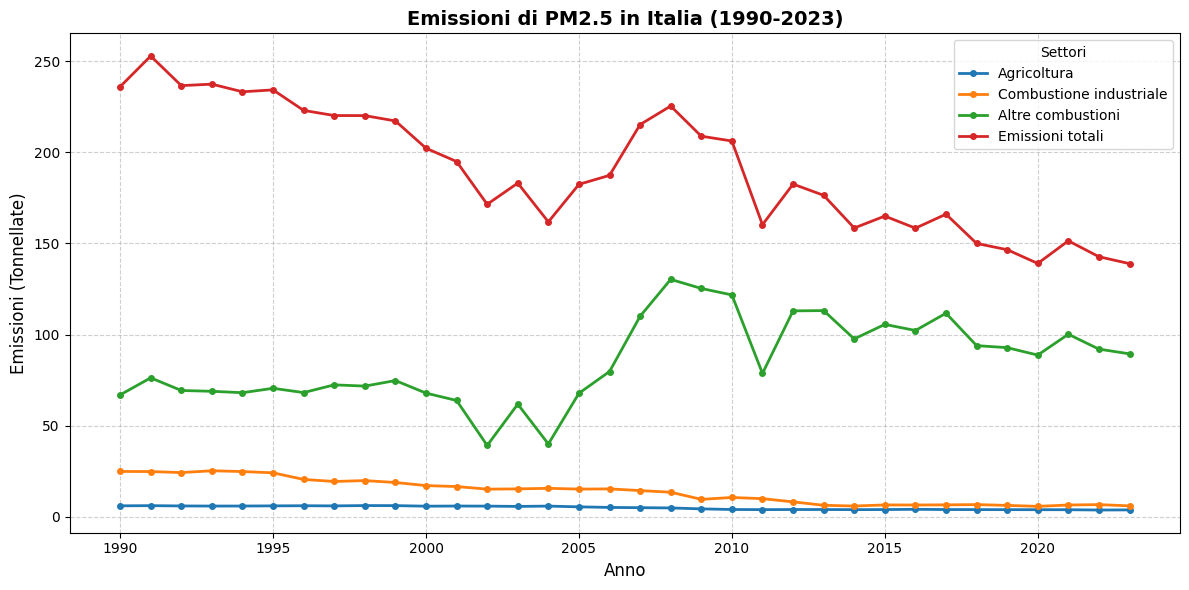

In [ ]:
import matplotlib.pyplot as plt

# 1. Data Trnsformation: Pivot
df_pulito = df_grezzo.pivot(index='TIME_PERIOD', columns='Measure', values='OBS_VALUE')

# 2.Translate column names to Italian for better readability and delete index name from columns
df_pulito.columns = ['Agricoltura', 'Combustione industriale', 'Altre combustioni', 'Emissioni totali']
df_pulito.columns.name = None

# 3.Display the first 5 rows to check
print("DATASET: DATI GREZZI")
display(df_pulito.head())

# 4.Graph
df_pulito.plot(figsize=(12, 6), linewidth=2, marker='o', markersize=4)
plt.title('Emissioni di PM2.5 in Italia (1990-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Emissioni (Tonnellate)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Settori')
plt.tight_layout()
plt.show()

LIVELLAMENTO: GRAFICO UNICO MA3 E MA5


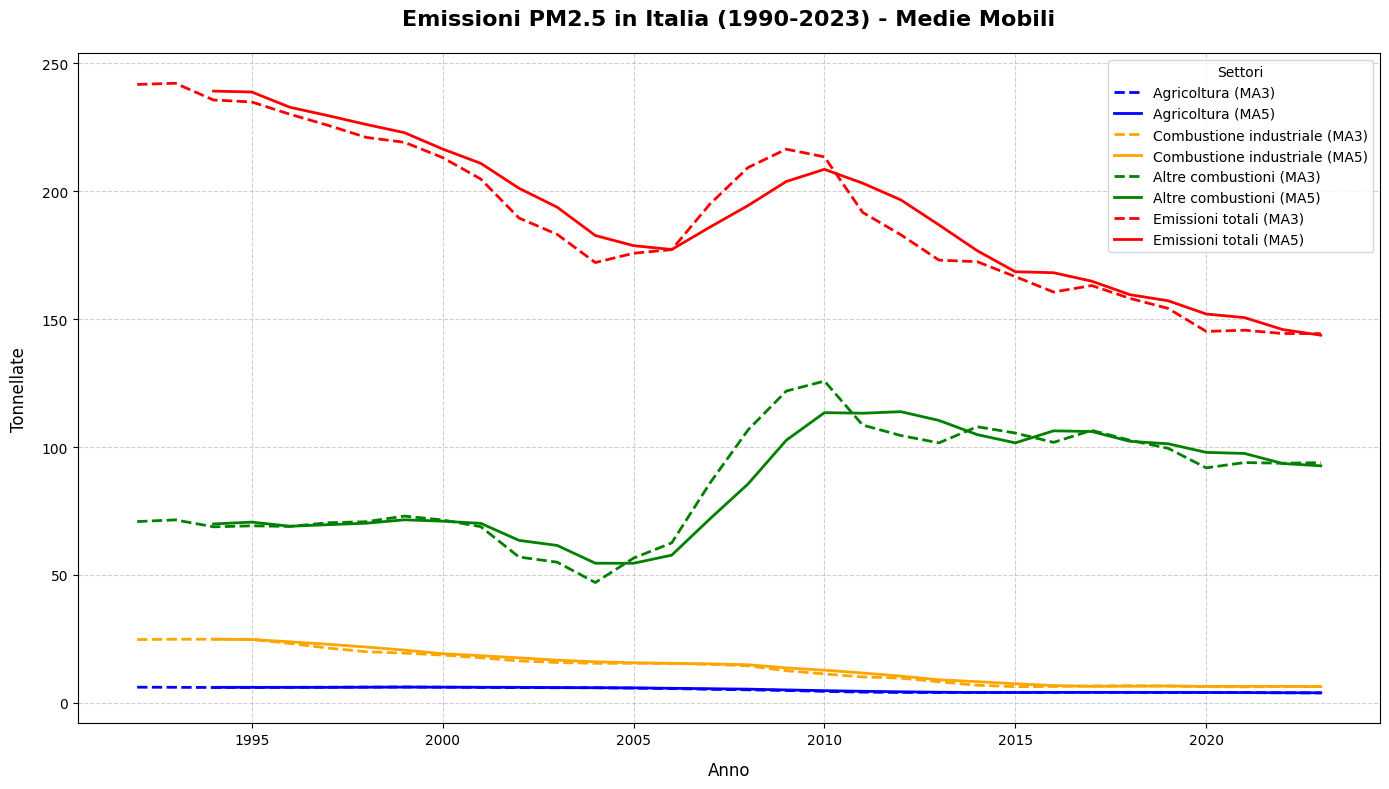

In [52]:
import matplotlib.pyplot as plt

print("LIVELLAMENTO: GRAFICO UNICO MA3 E MA5")

# 1. Calculate moving averages (3 and 5 years)
df_ma3 = df_pulito.rolling(window=3).mean()
df_ma5 = df_pulito.rolling(window=5).mean()

fig, ax = plt.subplots(figsize=(14, 8))

# 2. Colors for the graph
colori = {
    'Emissioni totali': 'red',
    'Altre combustioni': 'green',
    'Combustione industriale': 'orange',
    'Agricoltura': 'blue'
}

# 3. Plot lines for each sector
for settore in df_pulito.columns:
    colore = colori[settore] # Recuperiamo il colore semplice
    
    # MA3: 
    plt.plot(df_ma3.index, df_ma3[settore], 
             label=f'{settore} (MA3)', 
             color=colore, linestyle='--', linewidth=2)
     # MA5: 
    plt.plot(df_ma5.index, df_ma5[settore], 
             label=f'{settore} (MA5)', 
             color=colore, linestyle='-', markersize=8, linewidth=2)

# 4. Graph
plt.title('Emissioni PM2.5 in Italia (1990-2023) - Medie Mobili', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Anno', fontsize=12, labelpad=10)
plt.ylabel('Tonnellate', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Settori')
plt.tight_layout()
plt.show()



In [53]:
from statsmodels.tsa.stattools import adfuller

print("TEST DI DICKEY-FULLER (Analisi di Stazionarietà)")

# Dickey-Fuller test for each sector
for settore in df_pulito.columns:
    risultato = adfuller(df_pulito[settore].dropna())
    p_value = risultato[1] # just pick the p-value which is the second number
    
    print(f" Settore: {settore}")
    print(f"   P-value: {p_value:.4f}")
    
    # Check if p-value is < 0.05
    if p_value < 0.05:
        print(" ✔️ RISULTATO: STAZIONARIO (Non serve differenziare)\n")
    else:
        print(" ✖️  RISULTATO: NON STAZIONARIO (Serve differenziazione 'd' in ARIMA)\n")

TEST DI DICKEY-FULLER (Analisi di Stazionarietà)
 Settore: Agricoltura
   P-value: 0.9255
 ✖️  RISULTATO: NON STAZIONARIO (Serve differenziazione 'd' in ARIMA)

 Settore: Combustione industriale
   P-value: 0.6938
 ✖️  RISULTATO: NON STAZIONARIO (Serve differenziazione 'd' in ARIMA)

 Settore: Altre combustioni
   P-value: 0.2338
 ✖️  RISULTATO: NON STAZIONARIO (Serve differenziazione 'd' in ARIMA)

 Settore: Emissioni totali
   P-value: 0.6945
 ✖️  RISULTATO: NON STAZIONARIO (Serve differenziazione 'd' in ARIMA)



In [ ]:
from statsmodels.tsa.arima.model import ARIMA

print(" 1.1 MODELLO ARIMA ")

# 1. Select the column for the model
dati_storici = df_pulito['Emissioni totali'].dropna()

# 2. Train ARIMA model (order = p, d, q)
modello = ARIMA(dati_storici, order=(1, 1, 1), trend='t')
modello_AR = modello.fit()

# 3. Make prediction for the next 7 years
previsione = modello_AR.get_forecast(steps=7)
valori_previsti = previsione.predicted_mean
intervalli = previsione.conf_int()
print(modello_AR.summary())



 1.1 MODELLO ARIMA 
                               SARIMAX Results                                
Dep. Variable:       Emissioni totali   No. Observations:                   34
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -133.387
Date:                Sat, 28 Mar 2026   AIC                            274.774
Time:                        17:17:42   BIC                            280.760
Sample:                             0   HQIC                           276.788
                                 - 34                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -3.0948      2.322     -1.333      0.183      -7.645       1.455
ar.L1         -0.6286      0.351     -1.790      0.073      -1.317       0.060
ma.L1          0.3349      0.459

c:\Users\franc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\franc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\franc\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\franc\AppData\Local\Programs\Python\Python313\Lib

1.2 VISUALIZZAZIONE PREVISIONE 


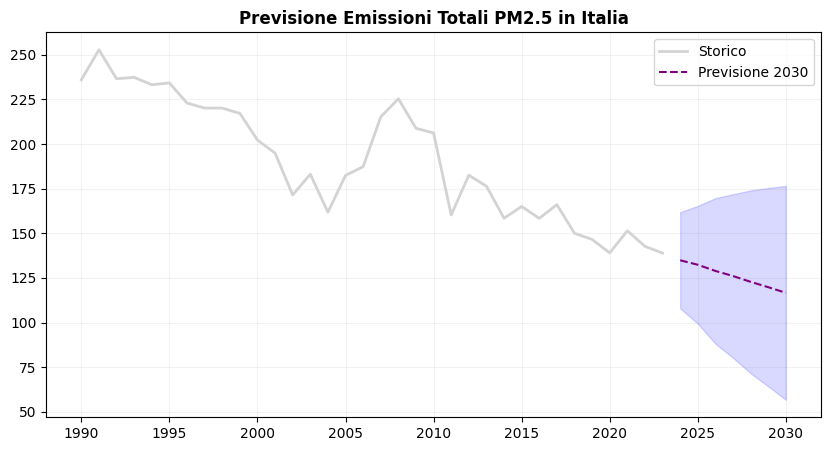

In [ ]:
import matplotlib.pyplot as plt

print("1.2 VISUALIZZAZIONE PREVISIONE ")

# 1. Set the future years (2024-2030)
anni_futuri = range(2024, 2031)
valori_previsti.index = anni_futuri
intervalli.index = anni_futuri

plt.figure(figsize=(10, 5))

# 2. Plot the Past
plt.plot(dati_storici.index, dati_storici, color='lightgrey', label='Storico', linewidth=2)

# 3. Plot the Future
plt.plot(valori_previsti.index, valori_previsti, color='purple', linestyle='--', label='Previsione 2030')

# 4. Confidence interval
plt.fill_between(intervalli.index, intervalli.iloc[:, 0], intervalli.iloc[:, 1], color='blue', alpha=0.15)

# 5. Graph
plt.title('Previsione Emissioni Totali PM2.5 in Italia', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.1, color='grey')
plt.show()